In [2]:
#--------------------------------------------
# 1 Importing Libraries
#--------------------------------
import pandas as pd                # For data manipulation
import numpy as np                 # For numerical operations
import matplotlib.pyplot as plt    # For plottig
import seaborn as sns              # for advanced visualizations

# Set a clean visualization style
plt.style.use('seaborn-v0_8')

In [3]:
# loading the dataset
# replace 'ai_adoption_dataset.csv' with your actual file path
df = pd.read_csv("ai_adoption_dataset.csv")
# check the first 5 rows to understand the data
print(df.head())
# check dataset information: number of rows, columns, data types, missing values
print(df.info())
# check for missing values in each column
print(df.isnull().sum())
# basic statistical overview of numerical columns
print(df.describe())

     country        industry           ai_tool  adoption_rate  \
0        USA      Technology           ChatGPT          40.45   
1     France   Manufacturing        Midjourney          35.72   
2  Australia  Transportation           ChatGPT          13.47   
3         UK   Manufacturing           ChatGPT          48.46   
4         UK     Agriculture  Stable Diffusion          34.06   

   daily_active_users  year  \
0                2461  2023   
1                8496  2024   
2                8641  2024   
3                3488  2023   
4                1124  2024   

                                       user_feedback age_group company_size  
0  YyvLXOFyevRMSvJtkXodLvgejiqQNvSOZfeeJASDOVTxwm...     35-44      Startup  
1  AdFVhenjthYSKJNzxzfaGQk wLnjRCgrHTyfXQEFjFJCMO...     18-24   Enterprise  
2  zgNPmXBICRNbpjpTqIUWmMTeTYsInDNtAmzuxpDvcUZEAi...     45-54      Startup  
3  LxeKzQFbPvhxXUSgPVlLLJ pUFaicjCgiMtAmsTjovkrdE...     45-54   Enterprise  
4  IOQtQoSKdSmiXRsUKpjXjXZgQohym

In [5]:
df.dtypes

country                object
industry               object
ai_tool                object
adoption_rate         float64
daily_active_users      int64
year                    int64
user_feedback          object
age_group              object
company_size           object
dtype: object

In [7]:
#-----------------------------------
# 3 Data Cleaning
#-----------------------------

# 3.1 drop dulicate rows if any
df = df.drop_duplicates()

# 3.2 handle missing values
# fill numerical columns with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# fill categorical olumns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3.3 verify no missing values remain
print(df.isnull().sum())

country               0
industry              0
ai_tool               0
adoption_rate         0
daily_active_users    0
year                  0
user_feedback         0
age_group             0
company_size          0
dtype: int64


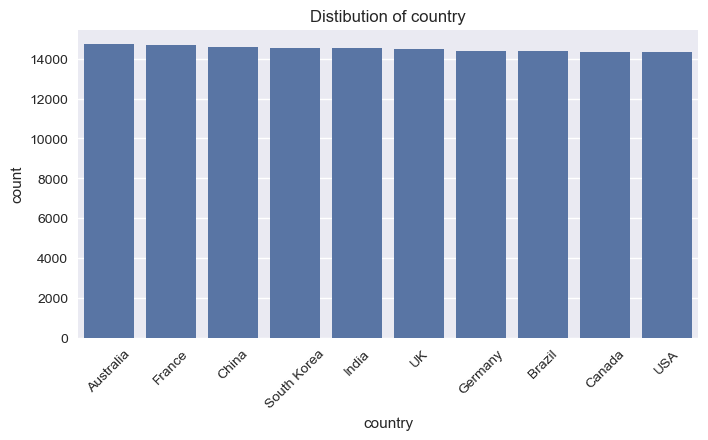

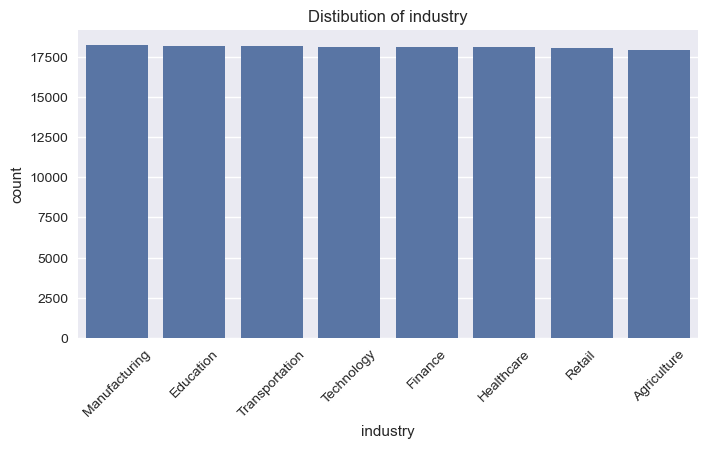

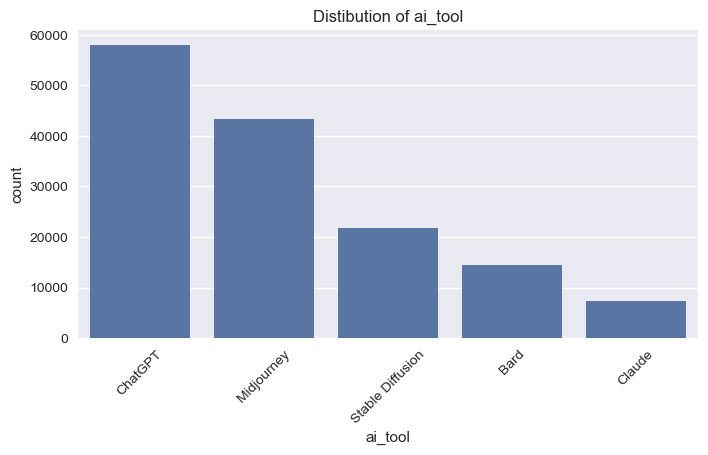

In [ ]:
#----------------------
# univariate analysis
#---------------------------
# analyze categorical variabes
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distibution of {col}')
    plt.xticks(rotation=45)
    plt.show()

# analyze numerical variables
df[num_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution f Numerical Columns")
plt.show()

In [ ]:
#------------------------------------------
# 5 bivariate analysis
# ---------------------------------------------

# 5.1 correlation between numerical features
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Numerical Features')
plt.how()

# 5.2 Examples: AI adoption rate vs industry
plt.figure(figsize(12,6))
sns.barplot(data=df, x='Industry', y='Adoption_Rate', order=df.groupby('Industry')['Adoption_Rate'].mean().sort_values(ascending=False).index)
plt.xticks(rotation=45)
plt.title('AI Adoption Rate by Industry')
plt.show()

#5.3 examples: popular AI Tool Count
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='popular_AI_Tool', order=df['Popular_AI_Tool'].value_counts().index)
plt.title('Most Popular AI Tools')
plt.xticks(rotation=45)
pt.show()

In [ ]:
#----------------------------------------------
# 6 Insights & Summary
#---------------------------------

# Insight examples:
#- identify industries with highest AI adoption rates
#- find which AI tools are most widely used
#- determine sectors or regions wih lower adoption - potential opporunities
#- Visualize correlations to nderstand key drives of adoption
#- you can also have a cleaned dataset for further analysis
df.to_csv("ai_Adoption_cleaned.csv", index=False)

In [ ]:
#---------------------------------
# 